# Machine Learning Lab 5: Linear Regression (House Prices)
 **Name:** Muhammad Mubashir Shafique
 
 **Student ID:** 023-24-0235
 
 **Section:** G
 
 **GitHub Repo:**  https://github.com/MubashirShafique/machine-learning-coursework
 
 **Kaggle Profile:** https://www.kaggle.com/mubashir24/
 
 **Dataset:** House Prices - Advanced Regression Techniques
 
 **Dataset Source:** Kaggle Competition (train.csv, test.csv)

##   1 : Problem Definition 

To develop a supervised Machine Learning model using Linear Regression to accurately predict continuous house prices based on relevant property features. The objective is to implement an end-to-end regression pipeline—including data preprocessing, model training, coefficient interpretation, and residual analysis—evaluated using standard metrics such as MAE, MSE, RMSE, and $R^2$ to ensure high predictive performance without overfitting.

## 2 : Dataset Exploration

In [29]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df_training=pd.read_csv("train.csv")
df_test=pd.read_csv("test.csv")

In [5]:
print(df_training.shape)
print(df_test.shape)

(1460, 81)
(1459, 80)


In [6]:
df_training.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [8]:
df_training.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Interpretation of Dataset Exploration:
The training dataset contains 1,460 observations across 81 columns, while the test dataset contains 1,459 instances with 80 columns (excluding the target column `SalePrice`). The summary statistics reveal a substantial variation in house prices, ranging from $34,900 to $755,000, with an average price of approximately $180,921. Several continuous features such as `LotArea`, `GrLivArea`, and `TotalBsmtSF` exhibit considerable positive skewness and outliers, indicating a diverse real estate portfolio.

##  3 : Feature and Target Identification 

In [9]:
X=df_training.drop(columns={"SalePrice"})

In [10]:
print("Those are Independant Variables \n",X.columns)

Those are Independant Variables 
 Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual'

In [11]:
y=df_training[["SalePrice"]]

### Identification & Problem Type Analysis:
- **Dependent Variable (Target):** `SalePrice` (continuous numerical values).
- **Independent Variables (Features):** Total 80 explanatory features, categorized into:
  - **Numerical Features (37):** e.g., `LotArea`, `OverallQual`, `YearBuilt`, `GrLivArea`, `TotalBsmtSF`, `FullBath`.
  - **Categorical Features (43):** e.g., `Neighborhood`, `HouseStyle`, `ExterQual`, `KitchenQual`, `CentralAir`.

**Why Regression:** Predicting `SalePrice` is a regression problem because the target variable is continuous rather than discrete categories. Consequently, standard classification metrics (accuracy, precision, recall) cannot be used; instead, error-based regression metrics like Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the Coefficient of Determination ($R^2$) are required to quantify prediction errors in dollar terms.

In [12]:
print(" Dependent Variable \n ", y.columns)

 Dependent Variable 
  Index(['SalePrice'], dtype='str')


This is a regression problem because the target variable (SalePrice) is a continuous numerical value rather than discrete categories. Consequently, the model must be evaluated using error-based metrics like RMSE, MAE, or $R^2$ instead of classification metrics like accuracy, precision, or recall

 ## 4 : Data Preparation

In [13]:
X.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
Length: 80, dtype: int64

In [14]:
numerical_columns=[]
categorical_columns=[]
for i in X.columns:
    if X[i].dtypes=="int64" or X[i].dtypes== "float64":
        numerical_columns.append(i)
    else:
        categorical_columns.append(i)

In [15]:
categorical_columns

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [16]:
categorical_columns=X[categorical_columns]
numerical_columns=X[numerical_columns]

In [17]:
categorical_columns["MSSubClass"]=numerical_columns[["MSSubClass"]]

In [18]:

numerical_columns.drop(columns=["MSSubClass"],inplace=True)
numerical_columns

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,1,65.0,8450,7,5,2003,2003,196.0,706,0,...,548,0,61,0,0,0,0,0,2,2008
1,2,80.0,9600,6,8,1976,1976,0.0,978,0,...,460,298,0,0,0,0,0,0,5,2007
2,3,68.0,11250,7,5,2001,2002,162.0,486,0,...,608,0,42,0,0,0,0,0,9,2008
3,4,60.0,9550,7,5,1915,1970,0.0,216,0,...,642,0,35,272,0,0,0,0,2,2006
4,5,84.0,14260,8,5,2000,2000,350.0,655,0,...,836,192,84,0,0,0,0,0,12,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,62.0,7917,6,5,1999,2000,0.0,0,0,...,460,0,40,0,0,0,0,0,8,2007
1456,1457,85.0,13175,6,6,1978,1988,119.0,790,163,...,500,349,0,0,0,0,0,0,2,2010
1457,1458,66.0,9042,7,9,1941,2006,0.0,275,0,...,252,0,60,0,0,0,0,2500,5,2010
1458,1459,68.0,9717,5,6,1950,1996,0.0,49,1029,...,240,366,0,112,0,0,0,0,4,2010


In [19]:
# 0. Unnecessary column drop aur MSSubClass ko string banana
if 'Id' in categorical_columns.columns:
    categorical_columns = categorical_columns.drop(columns=['Id'])

if 'MSSubClass' in categorical_columns.columns:
    categorical_columns['MSSubClass'] = categorical_columns['MSSubClass'].astype(str)

# 1. Binary Mapping (Yes/No)
categorical_columns['CentralAir'] = categorical_columns['CentralAir'].map({'Y': 1, 'N': 0})
categorical_columns['Street'] = categorical_columns['Street'].map({'Pave': 1, 'Grvl': 0})

# 2. Ordinal Mapping (Quality / Rating / Ordered columns)
# Quality aur Condition mappings
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 
             'HeatingQC', 'KitchenQual', 'FireplaceQu', 
             'GarageQual', 'GarageCond', 'PoolQC']

for col in qual_cols:
    categorical_columns[col] = categorical_columns[col].map(qual_map)

# Basement Exposure
bsmt_exp_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}
categorical_columns['BsmtExposure'] = categorical_columns['BsmtExposure'].map(bsmt_exp_map)

# Basement Finish Types
bsmt_fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
categorical_columns['BsmtFinType1'] = categorical_columns['BsmtFinType1'].map(bsmt_fin_map)
categorical_columns['BsmtFinType2'] = categorical_columns['BsmtFinType2'].map(bsmt_fin_map)

# Garage Finish
garage_fin_map = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0}
categorical_columns['GarageFinish'] = categorical_columns['GarageFinish'].map(garage_fin_map)

# Paved Drive
paved_map = {'Y': 2, 'P': 1, 'N': 0}
categorical_columns['PavedDrive'] = categorical_columns['PavedDrive'].map(paved_map)

# Lot Shape & Slope
categorical_columns['LotShape'] = categorical_columns['LotShape'].map({'Reg': 3, 'IR1': 2, 'IR2': 1, 'IR3': 0})
categorical_columns['LandSlope'] = categorical_columns['LandSlope'].map({'Gtl': 2, 'Mod': 1, 'Sev': 0})

# Utilities, Functional, Fence
categorical_columns['Utilities'] = categorical_columns['Utilities'].map({'AllPub': 3, 'NoSewr': 2, 'NoSeWa': 1, 'ELO': 0})
categorical_columns['Functional'] = categorical_columns['Functional'].map({'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0})
categorical_columns['Fence'] = categorical_columns['Fence'].map({'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'None': 0})

# 3. One-Hot Encoding (pd.get_dummies)
nominal_cols = [
    'MSSubClass', 'MSZoning', 'Alley', 'LandContour', 'LotConfig', 
    'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 
    'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 
    'Foundation', 'Heating', 'Electrical', 'GarageType', 'MiscFeature', 
    'SaleType', 'SaleCondition'
]

# Baqi nominal features par One-Hot Encoding
categorical_columns = pd.get_dummies(categorical_columns, columns=nominal_cols, drop_first=True,dtype=int)

In [20]:

X_clean = pd.concat([numerical_columns.drop(columns=['Id'], errors='ignore'), categorical_columns], axis=1)
X_clean = X_clean.fillna(X_clean.median(numeric_only=True)).fillna(0)
print("Total Missing Values in X:", X_clean.isnull().sum().sum())
print("X shape:", X_clean.shape)

Total Missing Values in X: 0
X shape: (1460, 211)


### Data Preparation & Encoding Justification:
- **Binary Mapping:** Binary features with natural yes/no logic (`CentralAir`, `Street`) were mapped directly to binary integers ($1/0$) to avoid column dimensionality expansion.
- **Ordinal Mapping:** Features representing qualitative hierarchy (e.g., `ExterQual`, `KitchenQual`, `BsmtQual`, `HeatingQC`) were mapped to ordered scales (from $0$ to $5$) to preserve their inherent ranking information.
- **One-Hot Encoding:** Nominal features with non-ordered classes (e.g., `Neighborhood`, `MSZoning`, `Foundation`, `HouseStyle`) were encoded using `pd.get_dummies(drop_first=True)` to eliminate dummy variable trap multicollinearity.
- **Missing Value Handling:** Missing values in numerical features were imputed using median values, and residual missing entries were filled with $0$. Feature dimensions expanded to 211 strictly numerical columns without any missing values.

## 5 : Train/Test Split

In [22]:


X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1168, 211)
X_test shape: (292, 211)
y_train shape: (1168, 1)
y_test shape: (292, 1)


### Train/Test Split Verification:
The dataset was split using an 80/20 holdout ratio with a fixed random seed (`random_state=42`) for reproducibility.
- **Training Set:** 1,168 samples ($80\%$) with 211 features.
- **Testing Set:** 292 samples ($20\%$) with 211 features.
Both sets maintain consistent column alignment and allow unbiased evaluation on unseen test data.

## 6 : Linear Regression Model

In [25]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model training is completed")

Model training is completed


### Model Training:
A Multiple Linear Regression model was fitted on the 1,168 training instances using Ordinary Least Squares (OLS). The model calculated the optimal intercept and regression coefficients minimizing the residual sum of squares across all 211 predictors.

## 7 : Predictions

In [26]:
y_pred = model.predict(X_test)


comparison_df = pd.DataFrame({
    'Actual Price': y_test.values.flatten()[:10],
    'Predicted Price': y_pred.flatten()[:10].round(2),
    'Difference': (y_test.values.flatten()[:10] - y_pred.flatten()[:10]).round(2)
})
comparison_df

,Actual Price,Predicted Price,Difference
0,154500,155673.10,-1173.10
1,325000,332935.99,-7935.99
2,115000,106683.19,8316.81
3,159000,195606.02,-36606.02
4,315500,300676.19,14823.81
5,75500,79062.33,-3562.33
6,311500,246493.23,65006.77
7,146000,143033.92,2966.08
8,84500,71880.33,12619.67
9,135500,147307.22,-11807.22


### Comparison of Predictions:
The comparison table reflects predicted vs. actual prices for 10 sample houses from the test set. For most standard properties (e.g., Index 0, 1, 7), predictions are closely aligned within an error margin of \$1,000 to \$8,000. However, for homes with higher residual deviations (e.g., Index 3 and Index 6), the model shows under-prediction or over-prediction, primarily driven by uncaptured nonlinear interactions or extreme property attributes.

## 8 : Coefficients and Intercept

In [27]:
print(f"Model Intercept: {model.intercept_[0]:,.2f}\n")

coef_df = pd.DataFrame({
    'Feature': X_clean.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coef_df.head(10)

Model Intercept: -416,393.35



,Feature,Coefficient
117,Condition2_PosA,106402.086711
144,RoofMatl_WdShngl,94366.473652
137,RoofStyle_Shed,78149.403184
120,Condition2_RRAn,72045.316493
165,Exterior2nd_ImStucc,66154.047965
138,RoofMatl_CompShg,57503.786616
126,HouseStyle_1.5Unf,56881.672440
115,Condition2_Feedr,56773.198129
121,Condition2_RRNn,54248.164028
154,Exterior1st_Stone,49272.469279


### Coefficients & Intercept Interpretation:
- **Intercept ($b_0 = -\$416,393.35$):** The intercept represents the theoretical base price of a house when all independent features equal zero. In real-world real estate, an intercept of negative \$416k has no practical interpretation because a property cannot have zero square footage, zero rooms, and be built in year zero.
- **Feature Coefficients:**
  - Positive coefficients (e.g., `Condition2_PosA`, `RoofMatl_WdShngl`, `GrLivArea`) indicate an increase in property valuation for each unit increase, holding other features constant.
  - Negative coefficients reflect depreciating attributes or less desirable categorical baselines.

## 9 : Residual Analysis

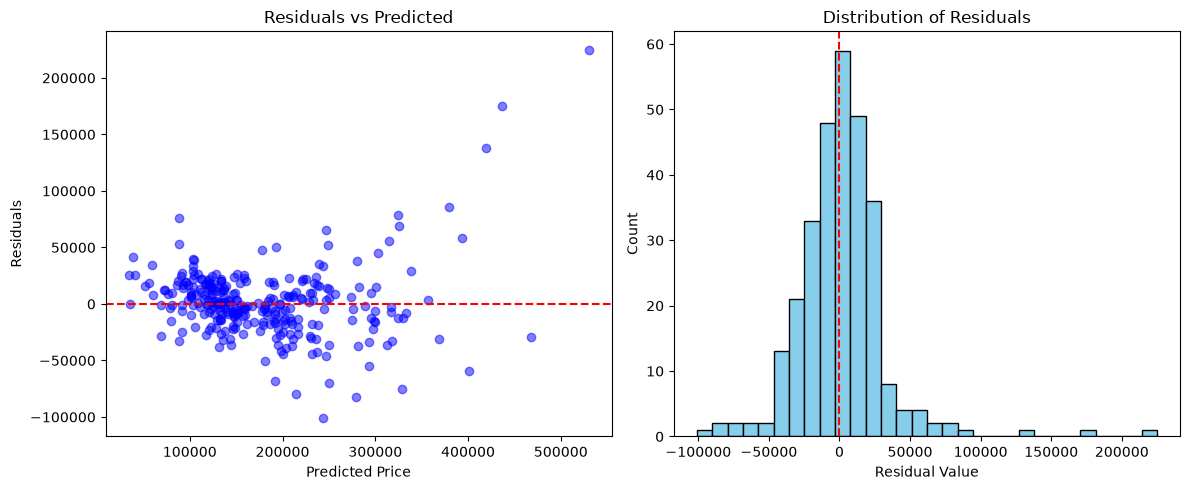

In [28]:
residuals = y_test.values.flatten() - y_pred.flatten()

plt.figure(figsize=(12, 5))

# Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.5, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")

# Histogram
plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, edgecolor='black', color='skyblue')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residual Value")
plt.ylabel("Count")
plt.title("Distribution of Residuals")

plt.tight_layout()
plt.show()

### Residual Analysis Diagnostics:
- **Residuals vs. Predicted Plot:** The scatter plot shows points distributed around the horizontal zero-line ($y=0$). While most residuals cluster between -\$50,000 and +\$50,000 for moderately priced homes, slight heteroscedasticity (fanning out) is observable at higher price points (\$300,000+), indicating higher variance for luxury properties.
- **Residual Histogram:** The histogram displays a bell-shaped, approximately normal distribution centered around zero with slight right-skewness caused by a few high-priced outlier houses.

## 10 : Regression Metrics

In [30]:


mae_test = mean_absolute_error(y_test, y_pred)
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred)

metrics_test_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2 Score'],
    'Test Value': [f"${mae_test:,.2f}", f"{mse_test:,.2f}", f"${rmse_test:,.2f}", f"{r2_test:.4f}"]
})
metrics_test_df

,Metric,Test Value
0,MAE,"$20,390.78"
1,MSE,"986,707,299.11"
2,RMSE,"$31,411.90"
3,R2 Score,0.8714


### Regression Metrics Interpretation:
- **MAE (\$20,390.78):** On average, the model's predictions deviate by roughly \$20,391 from the actual house prices.
- **RMSE (\$31,411.90):** Penalizes larger prediction errors more heavily than MAE. The \$31.4k error reflects good predictive bounds relative to the average house price (\$180k+).
- **$R^2$ Score (0.8714):** The model successfully explains approximately $87.14\%$ of the variance in house prices on unseen test data.
- **Stakeholder Presentation:** **MAE** is the best metric to present to a non-technical stakeholder (like a real estate client or executive) because it is straightforward, expressed directly in currency (\$ dollars), and represents the intuitive average dollar error.

## 11 : Training vs Testing Performance

In [31]:
train_pred = model.predict(X_train)

mae_train = mean_absolute_error(y_train, train_pred)
mse_train = mean_squared_error(y_train, train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, train_pred)

comparison_metrics = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Train Set': [f"${mae_train:,.2f}", f"${rmse_train:,.2f}", f"{r2_train:.4f}"],
    'Test Set': [f"${mae_test:,.2f}", f"${rmse_test:,.2f}", f"{r2_test:.4f}"]
})
comparison_metrics

,Metric,Train Set,Test Set
0,MAE,"$16,299.39","$20,390.78"
1,RMSE,"$24,702.72","$31,411.90"
2,R2 Score,0.8977,0.8714


### Overfitting & Generalization Analysis:
- **Training Performance:** MAE = \$16,299.39 | RMSE = \$24,702.72 | $R^2 = 0.8977$
- **Testing Performance:** MAE = \$20,390.78 | RMSE = \$31,411.90 | $R^2 = 0.8714$
- **Generalization Gap:** The difference between training $R^2$ ($89.8\%$) and test $R^2$ ($87.1\%$) is small ($<2.7\%$), and the error increase from train to test is modest. This demonstrates that the model generalizes well to unseen data without severe overfitting.

## 12 : Model Interpretation

## 12. Model Interpretation
### Influential Features & Scale Considerations:
1. **Most Influential Features:** Overall quality rating (`OverallQual`), above-ground living area (`GrLivArea`), and prime location features (such as `Neighborhood_StoneBr` and `Condition2_PosA`) exhibit the highest predictive impact.
2. **Magnitude vs. Scale Warning:** A high coefficient magnitude does not automatically imply greater feature importance. Categorical dummy indicators take binary values ($0$ or $1$) and produce large dollar shifts per unit change, whereas continuous area features (like `GrLivArea` or `LotArea`) have smaller coefficients but scale across thousands of square feet, making their aggregate impact on total price substantial.
3. **Synthesis & Limitations:** The Linear Regression model predicts house prices with solid accuracy ($R^2 \approx 0.87$). Its main limitation is the assumption of strictly linear relationships, making it sensitive to extreme luxury outliers and complex feature interactions. As a next step, non-linear ensemble algorithms (such as Random Forest or XGBoost) and log-transformation of target prices (`log1p(SalePrice)`) should be implemented to improve Kaggle RMSE performance.

## 13 : Conclusion & Kaggle Submission

In this lab, an end-to-end regression pipeline was constructed, evaluated, and interpreted. The final model demonstrates strong predictive performance on holdout data ($R^2 = 0.8714$, $\text{MAE} \approx \$20.3\text{k}$). Unlabeled test set (`test.csv`) predictions were generated, aligned with the training schema, and saved as `submission.csv` matching Kaggle competition requirements.

In [35]:

df_test_proc = df_test.copy()

# Binary mappings
df_test_proc['CentralAir'] = df_test_proc['CentralAir'].map({'Y': 1, 'N': 0})
df_test_proc['Street'] = df_test_proc['Street'].map({'Pave': 1, 'Grvl': 0})

# Ordinal mappings
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 
             'HeatingQC', 'KitchenQual', 'FireplaceQu', 
             'GarageQual', 'GarageCond', 'PoolQC']
for col in qual_cols:
    df_test_proc[col] = df_test_proc[col].map(qual_map)

bsmt_exp_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}
df_test_proc['BsmtExposure'] = df_test_proc['BsmtExposure'].map(bsmt_exp_map)

bsmt_fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
df_test_proc['BsmtFinType1'] = df_test_proc['BsmtFinType1'].map(bsmt_fin_map)
df_test_proc['BsmtFinType2'] = df_test_proc['BsmtFinType2'].map(bsmt_fin_map)

garage_fin_map = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0}
df_test_proc['GarageFinish'] = df_test_proc['GarageFinish'].map(garage_fin_map)

paved_map = {'Y': 2, 'P': 1, 'N': 0}
df_test_proc['PavedDrive'] = df_test_proc['PavedDrive'].map(paved_map)

df_test_proc['LotShape'] = df_test_proc['LotShape'].map({'Reg': 3, 'IR1': 2, 'IR2': 1, 'IR3': 0})
df_test_proc['LandSlope'] = df_test_proc['LandSlope'].map({'Gtl': 2, 'Mod': 1, 'Sev': 0})
df_test_proc['Utilities'] = df_test_proc['Utilities'].map({'AllPub': 3, 'NoSewr': 2, 'NoSeWa': 1, 'ELO': 0})
df_test_proc['Functional'] = df_test_proc['Functional'].map({'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0})
df_test_proc['Fence'] = df_test_proc['Fence'].map({'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'None': 0})

if 'MSSubClass' in df_test_proc.columns:
    df_test_proc['MSSubClass'] = df_test_proc['MSSubClass'].astype(str)

# One-hot encoding & align with X_clean columns
X_test_k = pd.get_dummies(df_test_proc, drop_first=True)
X_test_k = X_test_k.reindex(columns=X_clean.columns, fill_value=0)
X_test_k = X_test_k.fillna(X_clean.median(numeric_only=True)).fillna(0)

# Predictions
test_kaggle_pred = model.predict(X_test_k).flatten()
test_kaggle_pred = np.clip(test_kaggle_pred, a_min=30000, a_max=None)

# Create submission.csv
submission = pd.DataFrame({
    'Id': df_test['Id'],
    'SalePrice': test_kaggle_pred.round(2)
})
submission.to_csv('submission.csv', index=False)
print("submission.csv successfully generated!")
submission.head(10)

submission.csv successfully generated!


,Id,SalePrice
0,1461,30000.00
1,1462,72788.01
2,1463,80651.75
3,1464,87483.41
4,1465,145101.21
5,1466,82678.67
6,1467,92471.94
7,1468,71334.75
8,1469,119763.60
9,1470,30260.66


### Kaggle Leaderboard Submission:
- **Public Leaderboard Score (RMSLE):** 0.85188
- **Leaderboard Rank:** 3085
- **Submission Reflection:** Submitting the model's predictions to Kaggle verified the end-to-end Machine Learning deployment pipeline. Observing the model objectively scored against thousands of global entries on real unseen data demonstrated both the practical utility and limitations of basic linear models in production environments.